In [4]:
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
from operator import itemgetter
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import silhouette_score, adjusted_rand_score, homogeneity_score, normalized_mutual_info_score, adjusted_mutual_info_score, calinski_harabasz_score
from sklearn.metrics.cluster import contingency_matrix
warnings.filterwarnings("ignore")

def purity_score(y_true, y_pred):
    contingency_mat = contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_mat, axis=0)) / np.sum(contingency_mat) 

In [13]:
dataset = 'sim1'
label_dict = {'6_1':0,'6_2':1,'6_3':2,'6_4':3,'6_5':4} if dataset == 'sim1' else None
label_dict = {'9_1':0,'9_2':1,'9_3':2,'9_4':3,'9_5':4,'9_6':5,'9_7':6,'9_8':7} if dataset == 'sim2' else label_dict
label_dict = {'13_1':0,'13_2':1,'13_3':2,'13_4':3,'13_5':4,'13_6':5,'13_7':6,'13_8':7,'13_9':8,'13_10':9,'13_11':10,'13_12':11} if dataset == 'sim3' else label_dict
label_dict = {value: key for key, value in label_dict.items()}

cell clustering validation


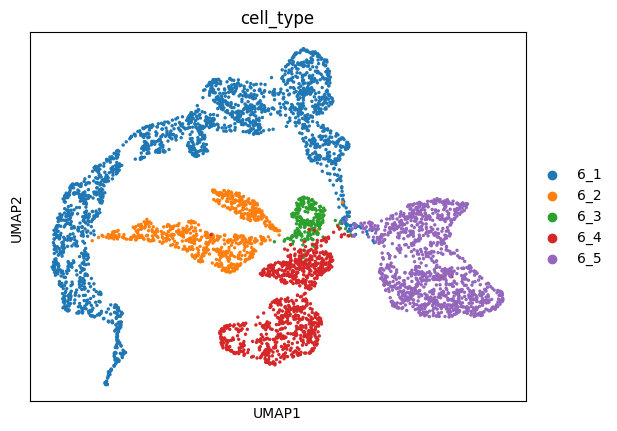

resolution: 0.1
resolution: 0.2
resolution: 0.3
resolution: 0.4
resolution: 0.5
resolution: 0.6
resolution: 0.7
resolution: 0.8
resolution: 0.9
resolution: 1.0
cell clustering results: ASW_learned = [0.21, 0.354, 0.352, 0.335, 0.341, 0.347, 0.335, 0.329, 0.319, 0.32], PS_learned = [0.973, 0.928, 0.979, 0.979, 0.979, 0.979, 0.979, 0.979, 0.979, 0.979], HS_learned = [0.912, 0.873, 0.94, 0.94, 0.94, 0.94, 0.953, 0.953, 0.953, 0.953]


In [14]:
# Unsupervised evaluation
print('cell clustering validation')
y_label = np.load('./data/simulation_dataset_1/lbls.npy')
x_ach = np.load('./result/embedding.npy')
ASW_learned, PS_learned, HS_learned = [], [], []
adata_learned = ad.AnnData(x_ach, obs=pd.DataFrame(index=[str(i) for i in range(x_ach.shape[0])]), var=pd.DataFrame(index=[str(i) for i in range(x_ach.shape[1])]))
adata_learned.obs['cell_type'] = itemgetter(*list(y_label))(label_dict)
sc.pp.neighbors(adata_learned, use_rep='X')
sc.tl.umap(adata_learned, n_components=2, random_state=0)
sc.pl.umap(adata_learned, color="cell_type")
plt.title('scMHNN')
plt.savefig('./result/scMHNN_umap_{}.jpg'.format(dataset), bbox_inches='tight', dpi=800)
plt.close()
for i in list(np.round(np.linspace(0.1, 1.0, 10), 1)):
    print('resolution:', i)
    sc.tl.louvain(adata_learned, resolution = i, key_added = "louvain") # clustering
    y_predict = adata_learned.obs['louvain']
    ASW_learned.append(np.round(silhouette_score(x_ach, y_predict), 3))
    PS_learned.append(np.round(purity_score(y_label, y_predict), 3))
    HS_learned.append(np.round(homogeneity_score(y_label, y_predict), 3))
print('cell clustering results: ASW_learned = {}, PS_learned = {}, HS_learned = {}'.format(ASW_learned, PS_learned, HS_learned))

In [11]:
# Supervised evaluation
print('cell annotation validation')
result_test = np.load('./result/result_test.npz')
df_result = pd.DataFrame()
df_result['acc'] = [np.round(accuracy_score(result_test['label'], result_test['pred']), 3)]
df_result['f1w'] = [np.round(f1_score(result_test['label'], result_test['pred'], average='weighted'), 3)]
df_result

cell annotation validation


,acc,f1w
0,0.963,0.963
